In [1]:
import pandas as pd
import numpy as np


In [2]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'

df_raw = pd.read_csv(filepath, decimal=',')
df_raw['date'] = pd.to_datetime(df_raw['date'])

lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df_raw.columns if c not in ['date'] + lab_cols]

time_offsets = pd.to_timedelta(df_raw.groupby('date').cumcount() * 20, unit='s')
df_raw.index = df_raw['date'] + time_offsets
df_raw = df_raw.drop(columns='date')

# El dataset original tiene un hueco real de 13 dias y 7h: la ultima lectura
# antes del hueco es 2017-03-16 05:00 y la siguiente es 2017-03-29 12:00 (no
# hay NaN en el CSV, simplemente no existen filas en ese intervalo). Se descarta
# todo lo anterior al hueco para quedarnos con un tramo continuo de datos.
cutoff = pd.Timestamp('2017-03-29 12:00:00')
df_raw = df_raw[df_raw.index >= cutoff]

# df: agregacion horaria (valor promedio) - se usa para todo el notebook salvo
# que se necesiten variaciones intrahora, en cuyo caso se usa df_raw (crudo a 20s)
df = df_raw.resample('h').mean()

# Find missing values

In [3]:
# Conteo y % de NaN por columna (surgen del resample horario: una hora sin
# ninguna lectura original de 20s cae a NaN en el promedio)
nan_summary = pd.DataFrame({
    'n_nan': df.isna().sum(),
    'pct_nan': (df.isna().mean() * 100).round(2),
}).sort_values('n_nan', ascending=False)

print(f'Filas totales: {len(df)}')
nan_summary[nan_summary['n_nan'] > 0]


Filas totales: 3948


,n_nan,pct_nan


In [4]:
# Patron temporal de los NaN: horas completamente vacias tras el resample
# (indican huecos de tiempo donde no habia ninguna lectura original en esa hora)
rows_all_nan = df[sensor_cols].isna().all(axis=1)
print(f'Filas totalmente NaN (huecos de tiempo): {rows_all_nan.sum()} de {len(df)}')

if rows_all_nan.any():
    gap_dates = df.index[rows_all_nan]
    print('Primeras fechas con hueco:', gap_dates[:10].tolist())


Filas totalmente NaN (huecos de tiempo): 0 de 3948


# Noise filtering

In [5]:
# El filtrado de ruido opera sobre df_raw (crudo, cada 20s), no sobre df (agregado
# horario): el ruido de alta frecuencia que se quiere suavizar aqui ya desaparece
# solo al promediar por hora, asi que filtrar df horario no tendria sentido.

# --- EMA (alfa) filtering: causal, low-lag ---
# y[n] = alpha*x[n] + (1-alpha)*y[n-1]
# alpha equivalente a una media movil de "windowSize" en term de tiempo de asentamiento:
# alpha = 2 / (windowSize + 1) es la conversion estandar EMA <-> SMA
windowSize = 15
alpha = 2 / (windowSize + 1)

df_ema = df_raw[sensor_cols].ewm(alpha=alpha, adjust=False).mean()
for signal in sensor_cols:
    df_raw[signal + '_EMA'] = df_ema[signal]

# --- Savitzky-Golay causal ---
# El savgol_filter estandar es centrado (usa muestras futuras -> no es causal).
# Para hacerlo causal, se calculan los coeficientes SG evaluando el polinomio
# en el ULTIMO punto de la ventana (pos=windowSize-1) en vez del centro,
# y se aplican por convolucion (equivalente a "ajustar un polinomio a los
# ultimos N puntos y evaluar en el punto actual").
from scipy.signal import savgol_filter, savgol_coeffs

polyorder = 2
sg_causal_coeffs = savgol_coeffs(windowSize, polyorder, pos=windowSize - 1)

for signal in sensor_cols:
    # centrado, para comparar (usa muestras futuras, no valido en tiempo real)
    df_raw[signal + '_SG'] = savgol_filter(df_raw[signal], window_length=windowSize, polyorder=polyorder)
    # causal: convolucion con los coeficientes SG evaluados en el borde derecho
    df_raw[signal + '_SG_causal'] = np.convolve(df_raw[signal], sg_causal_coeffs, mode='full')[:len(df_raw)]


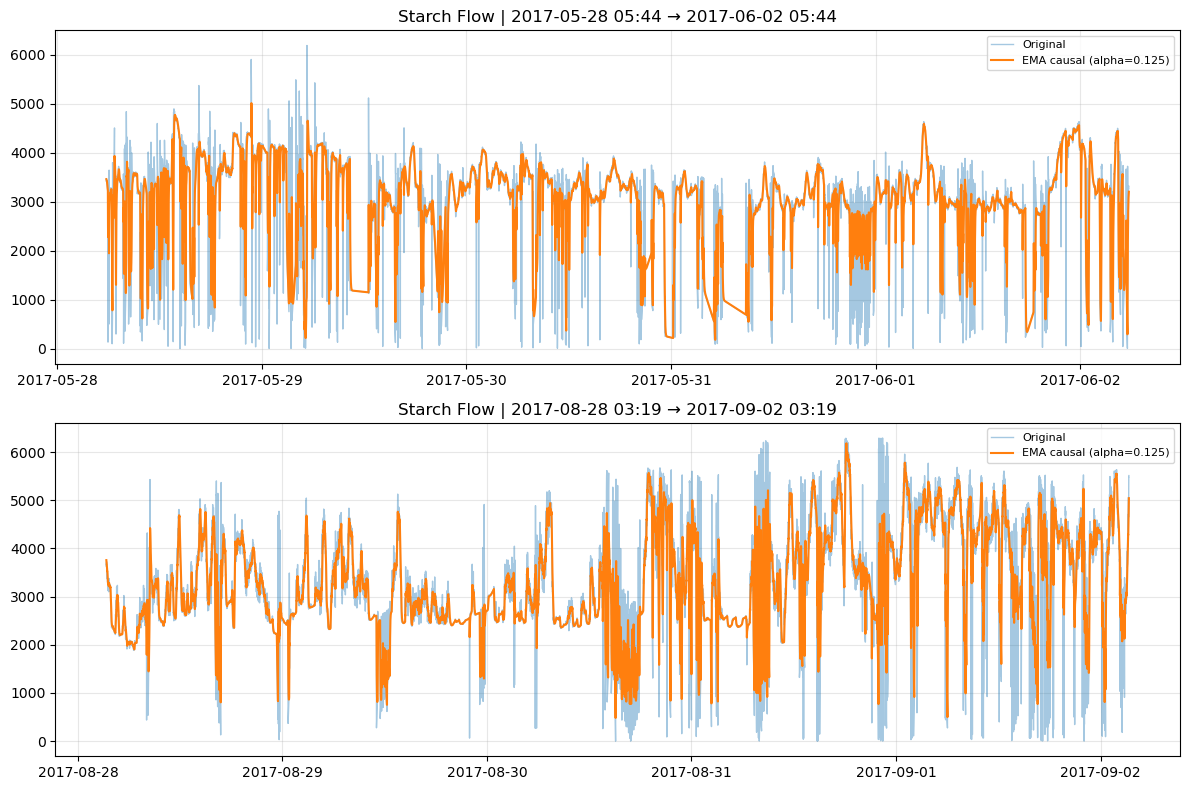

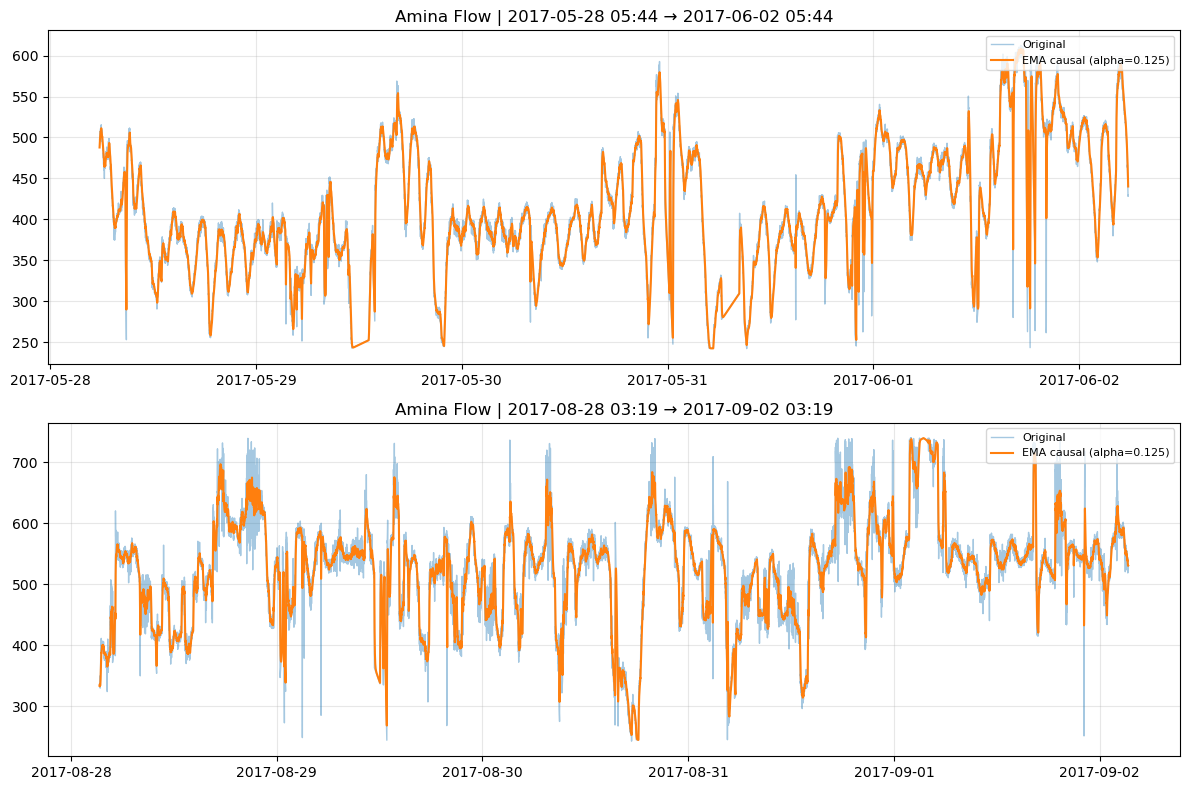

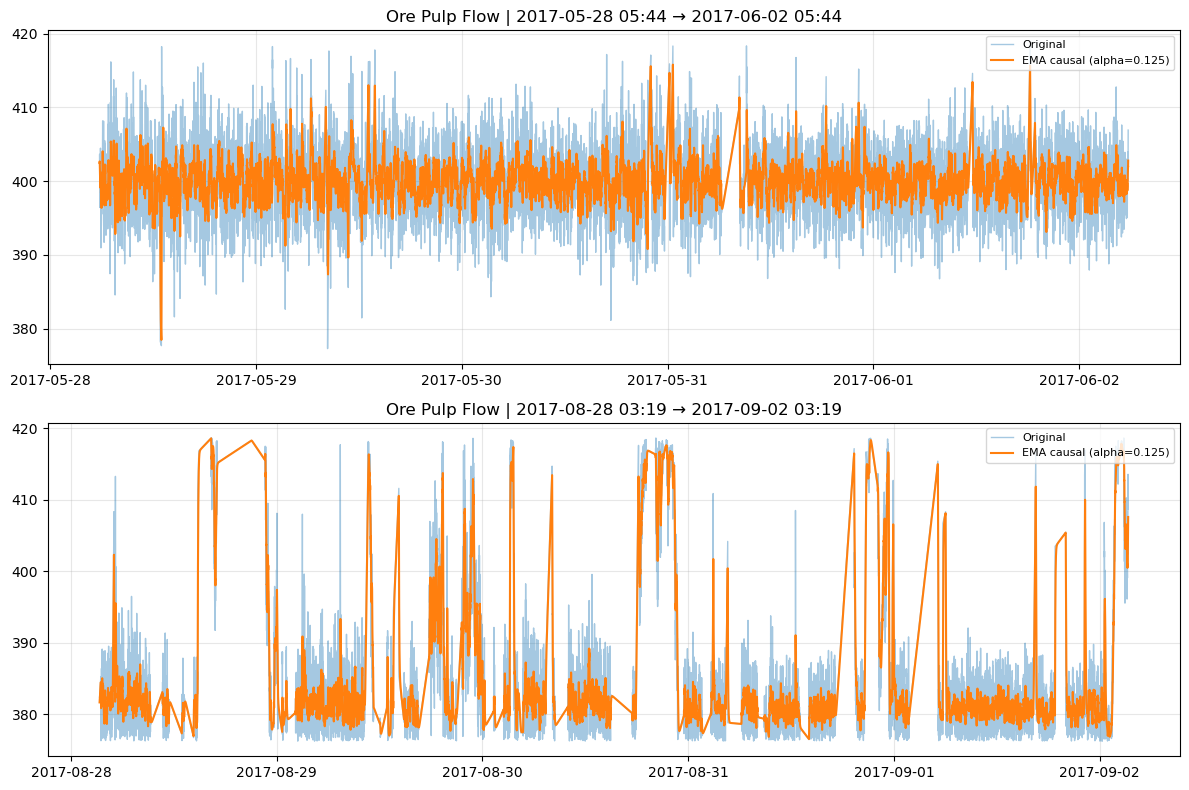

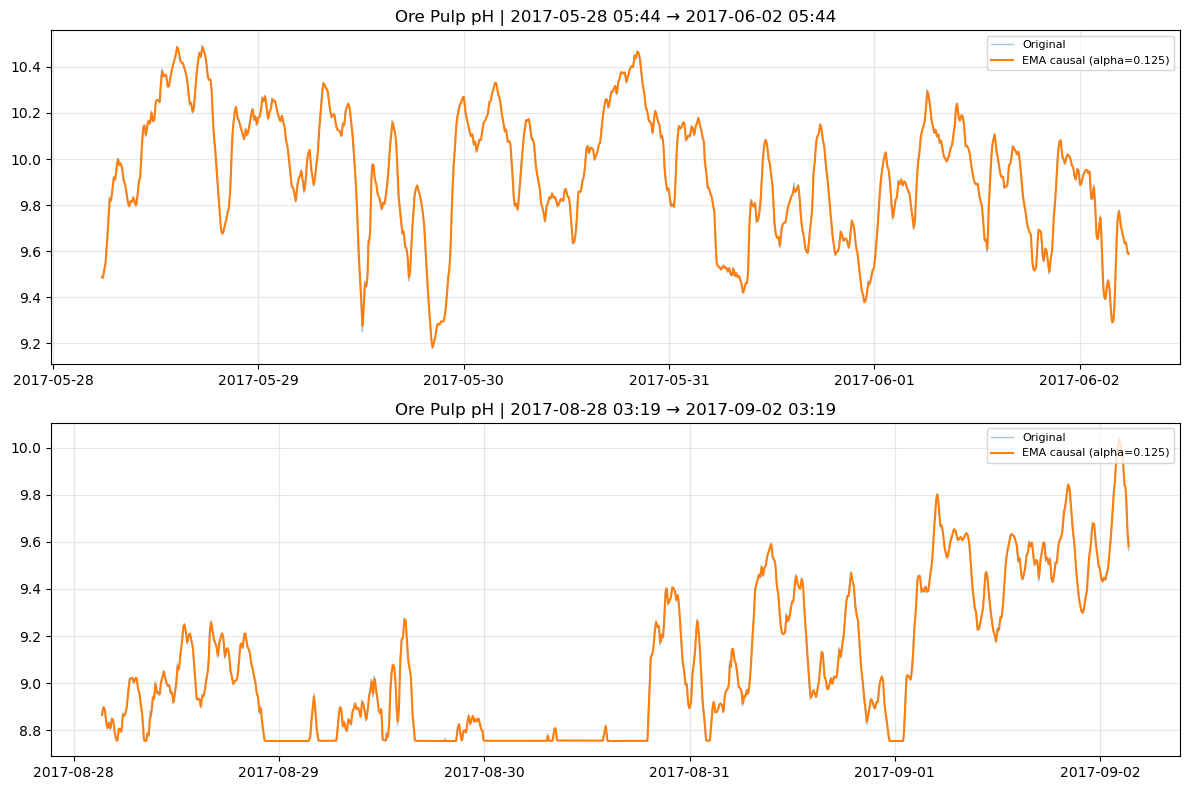

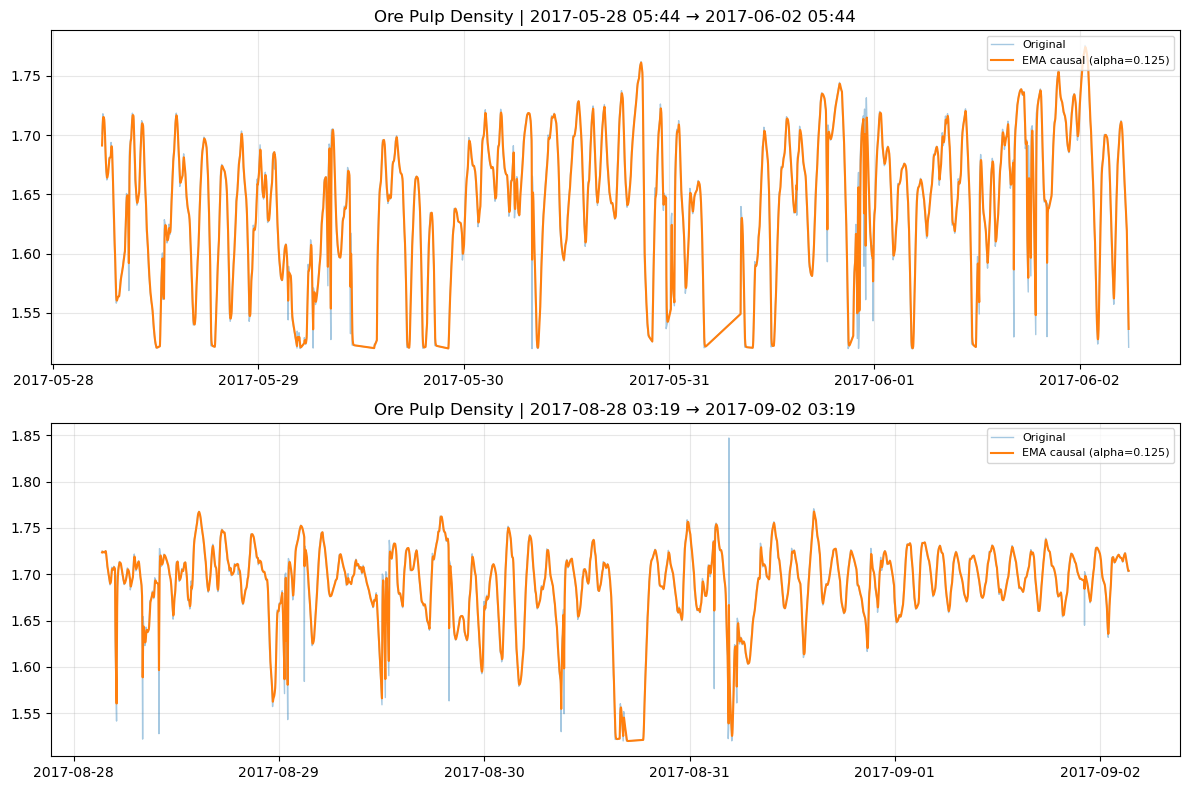

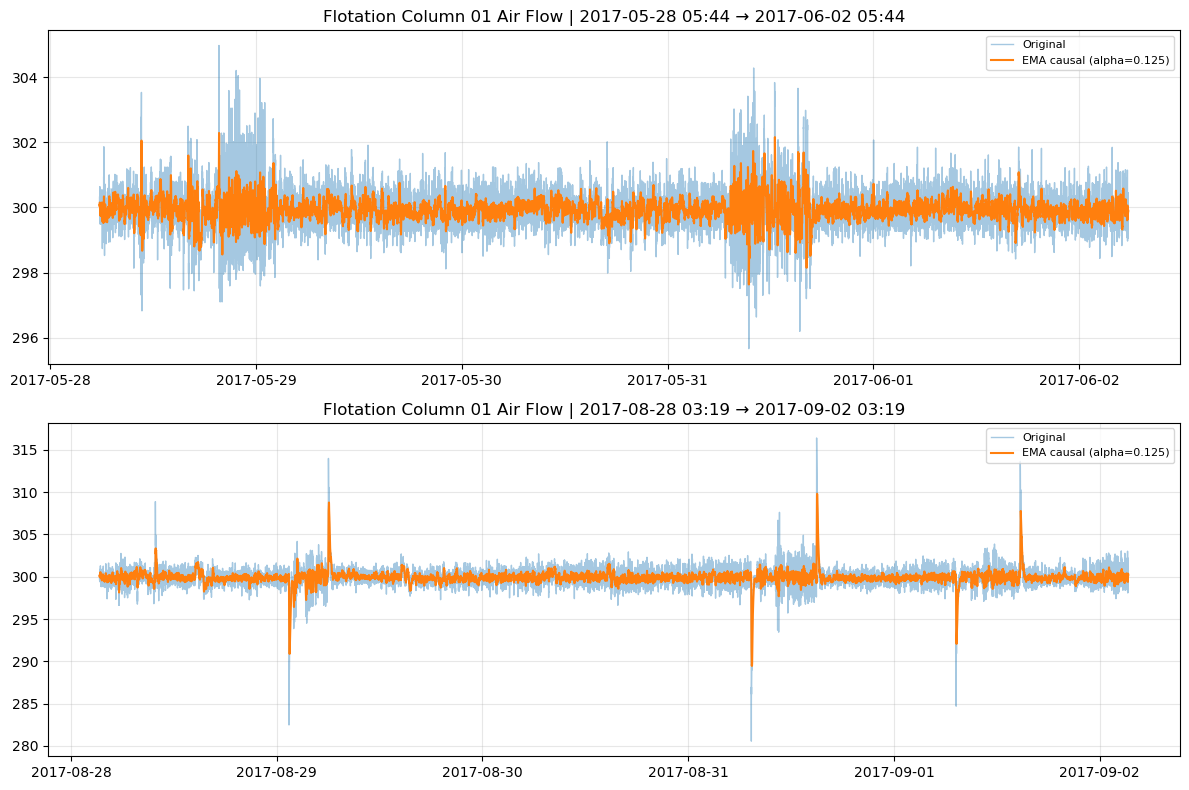

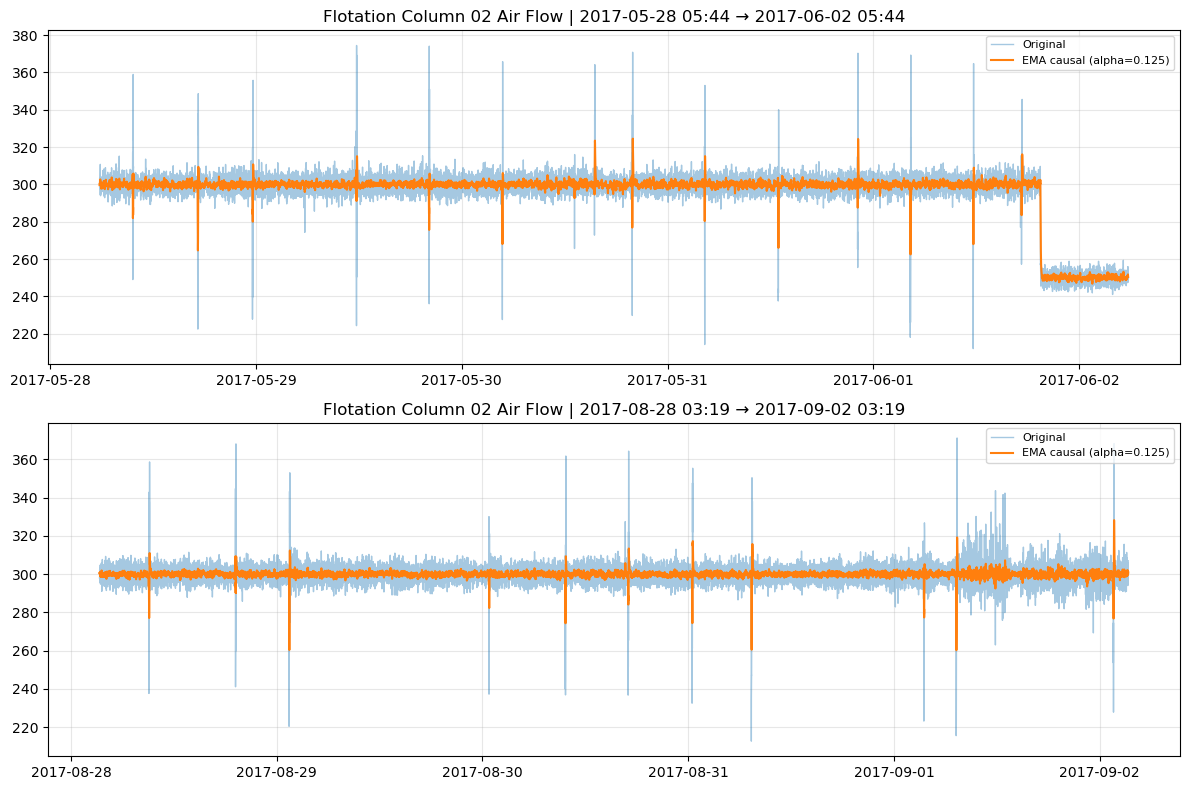

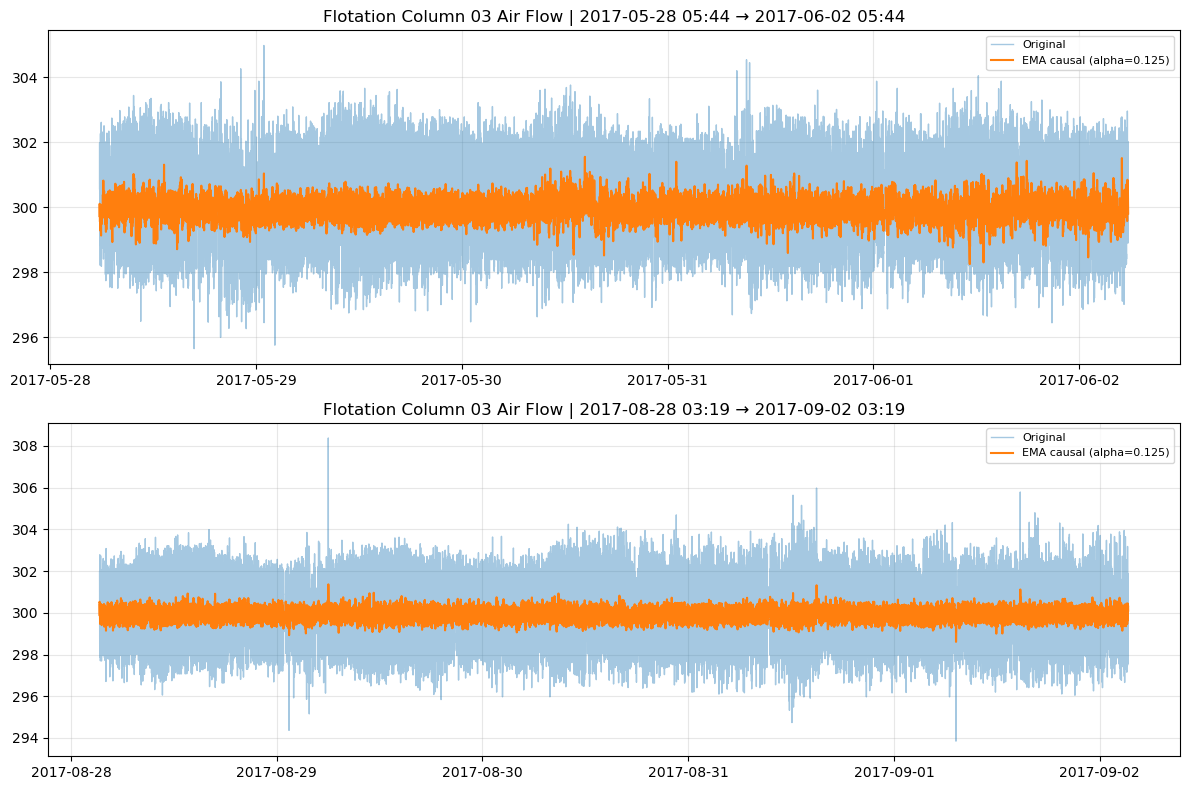

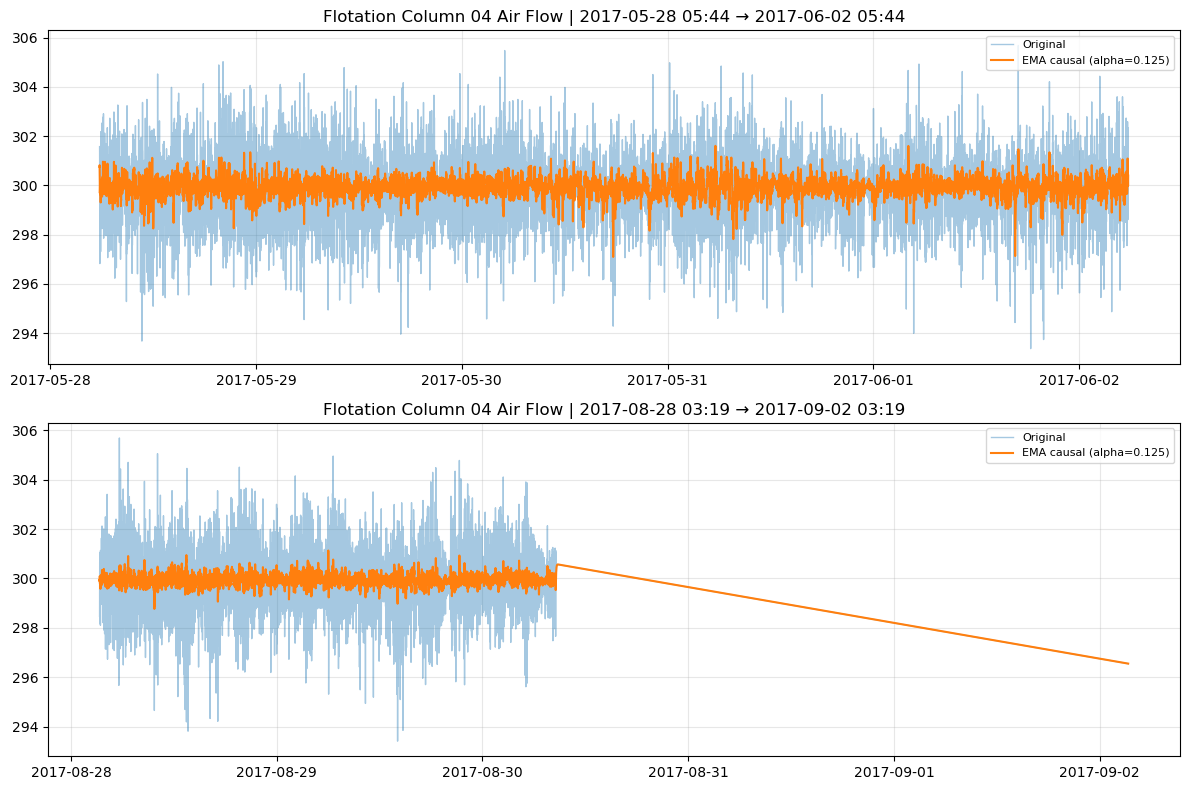

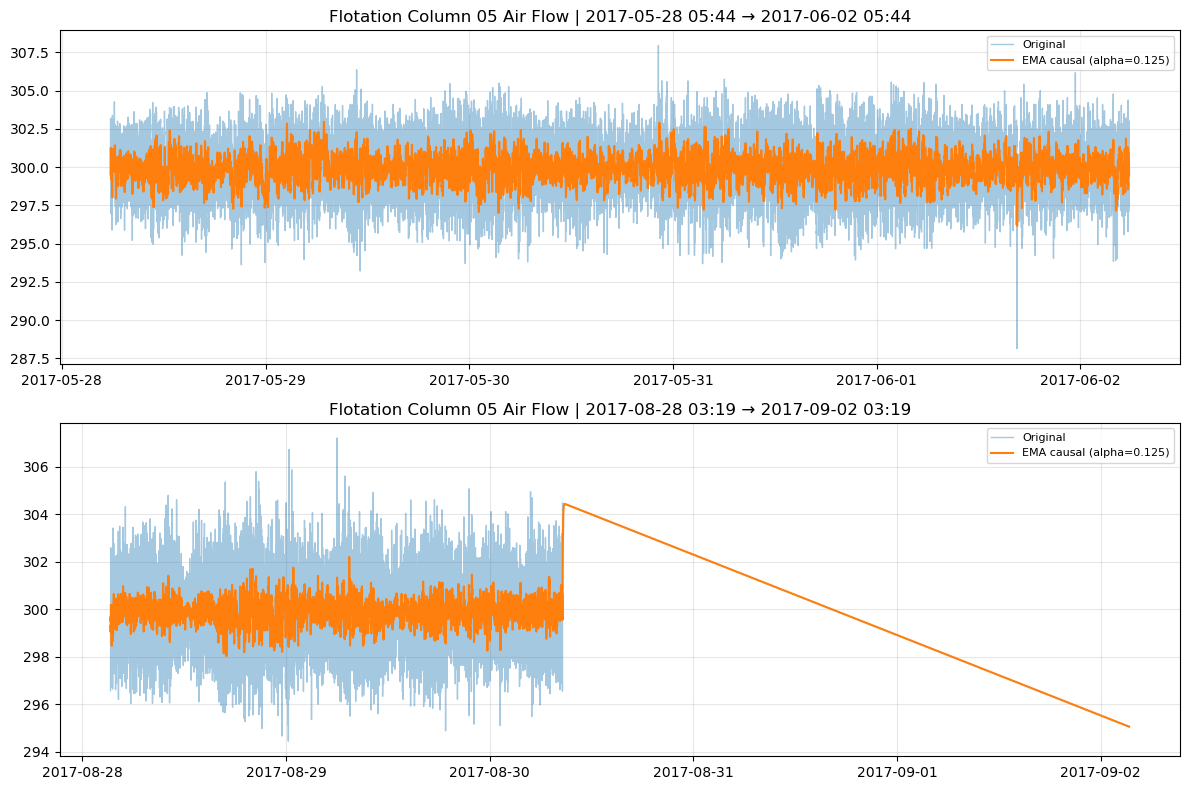

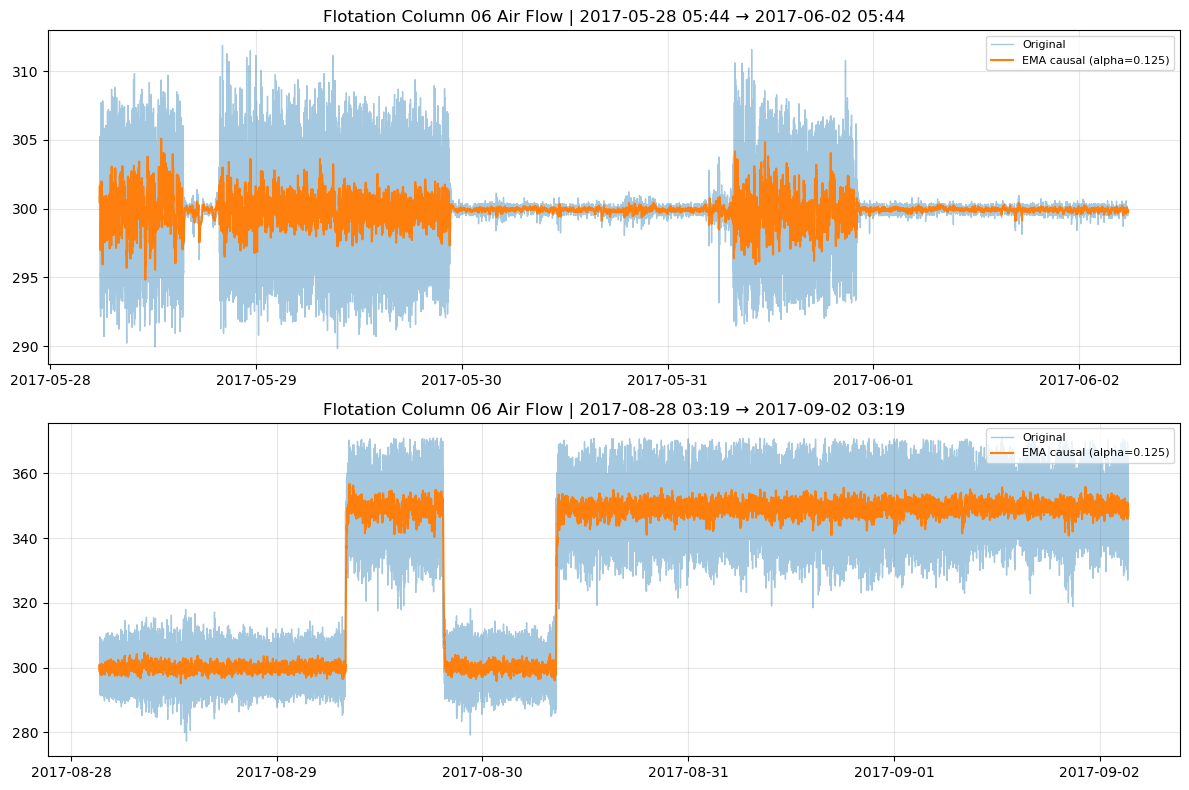

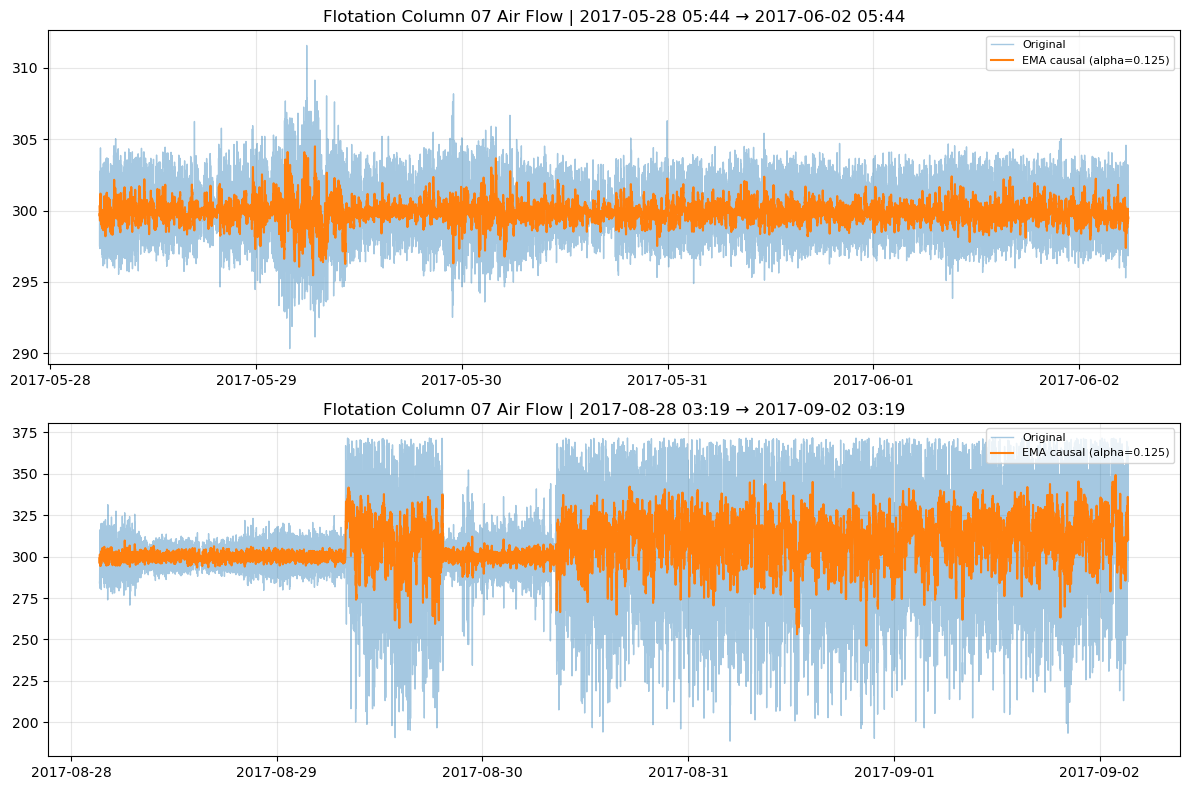

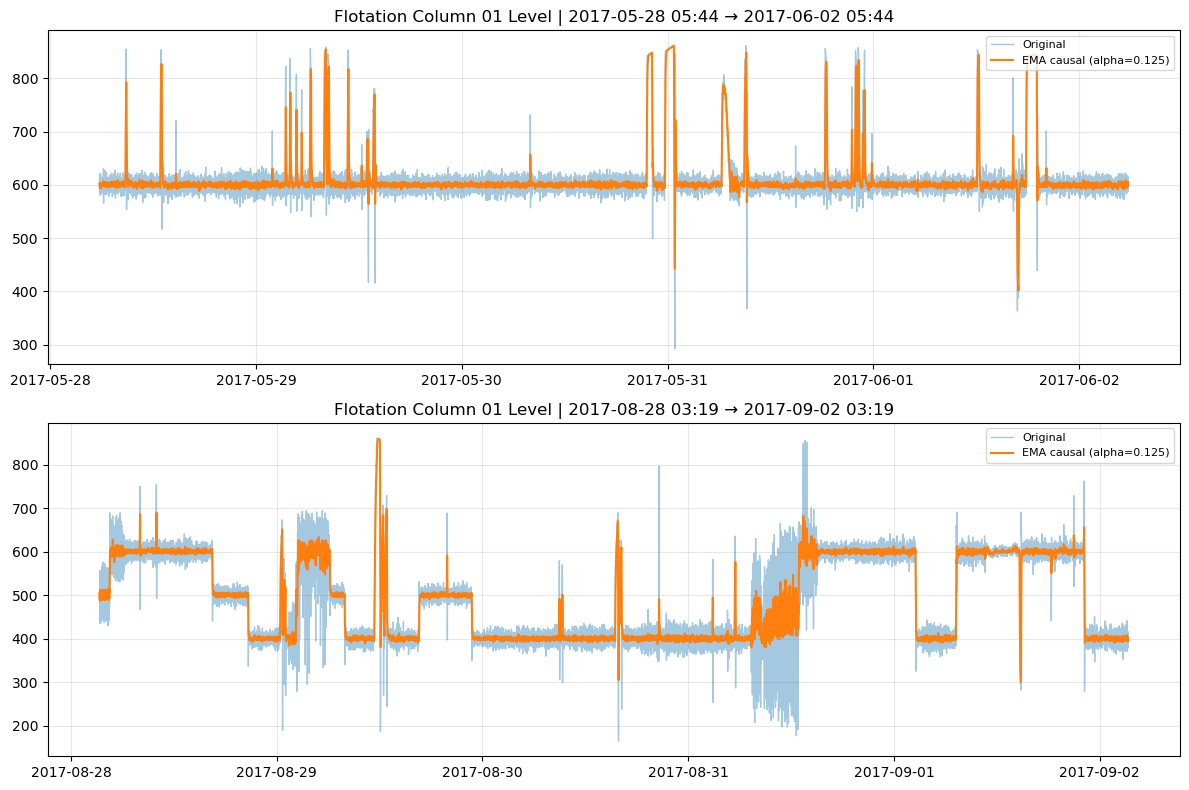

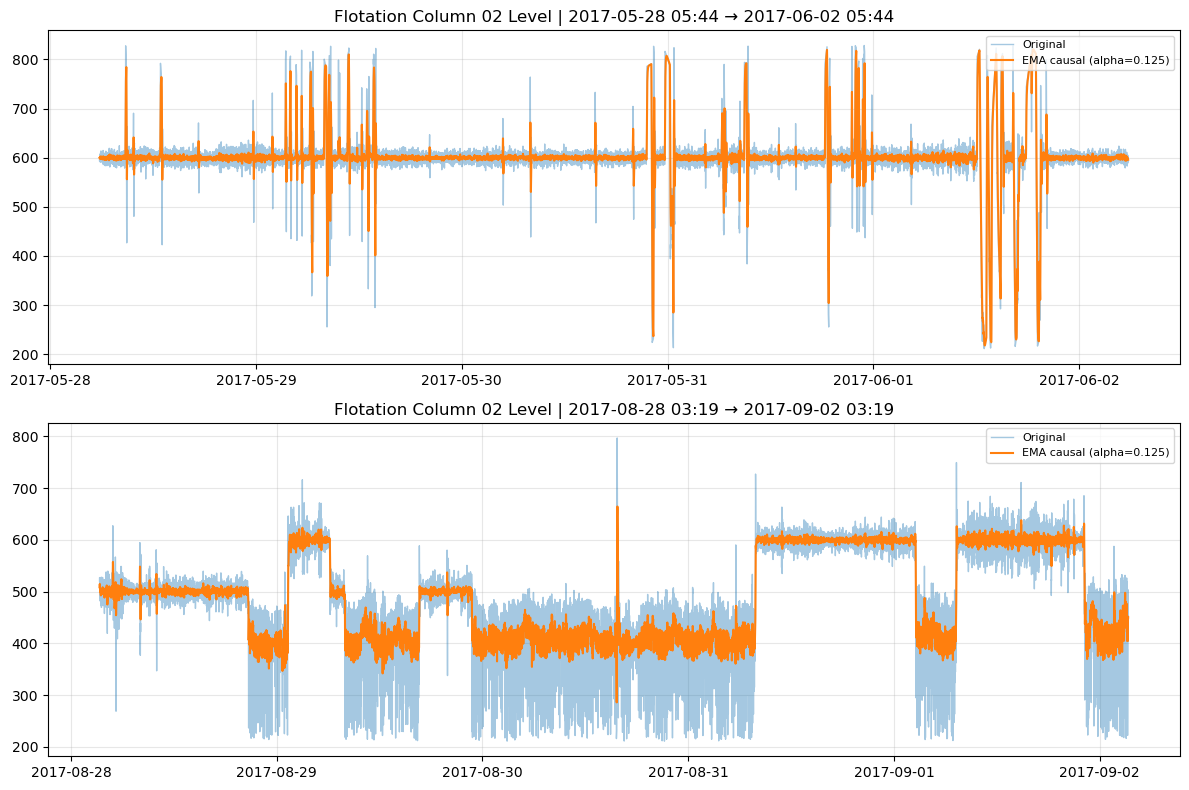

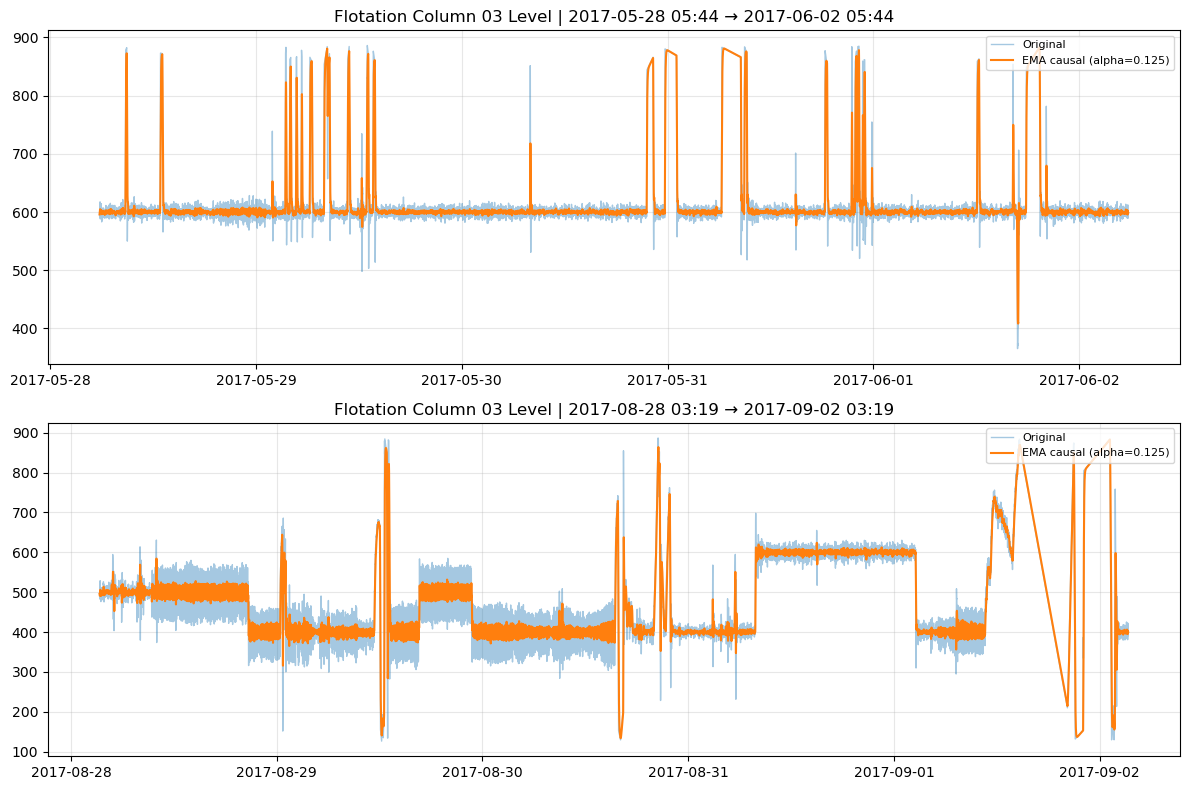

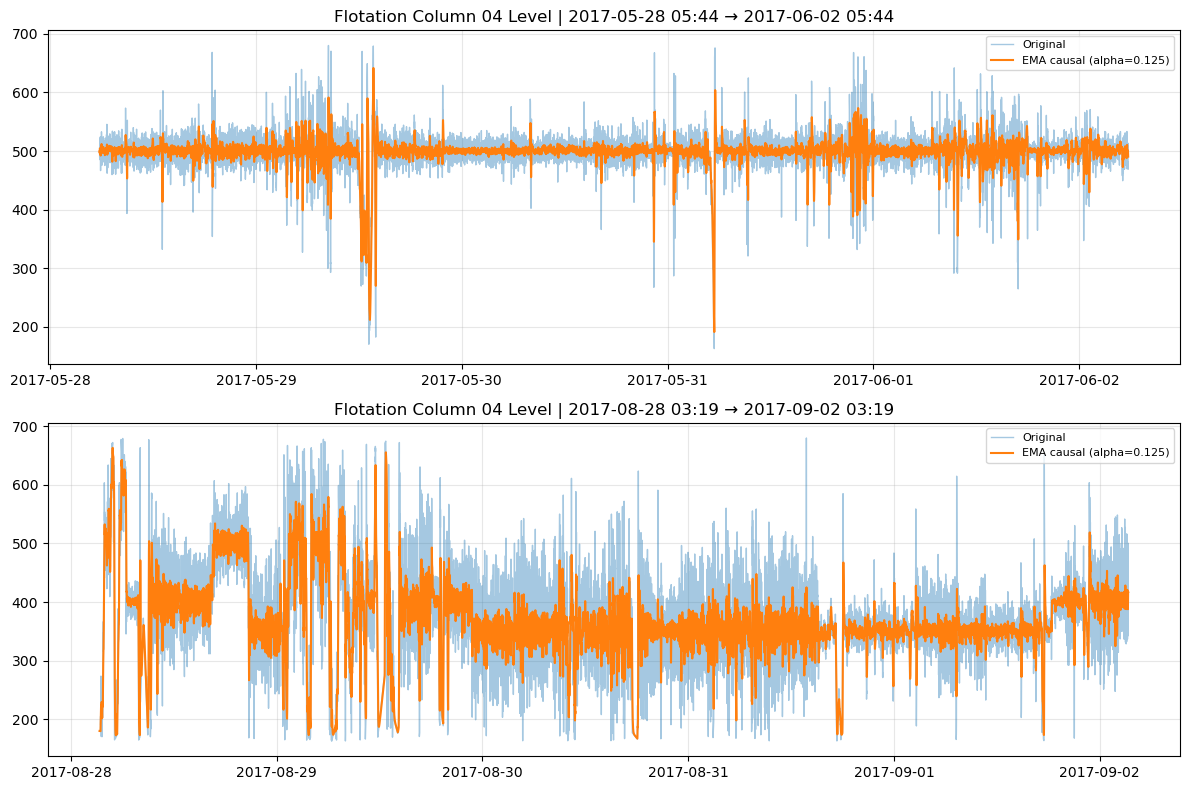

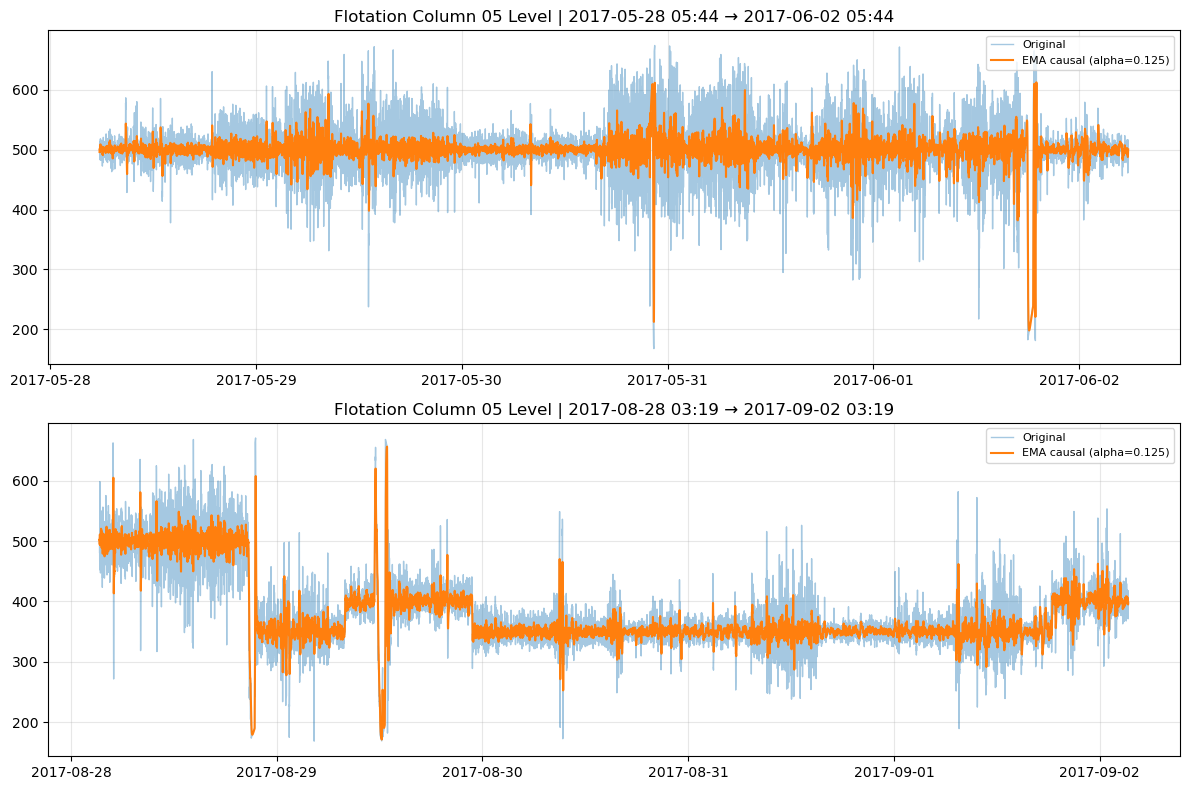

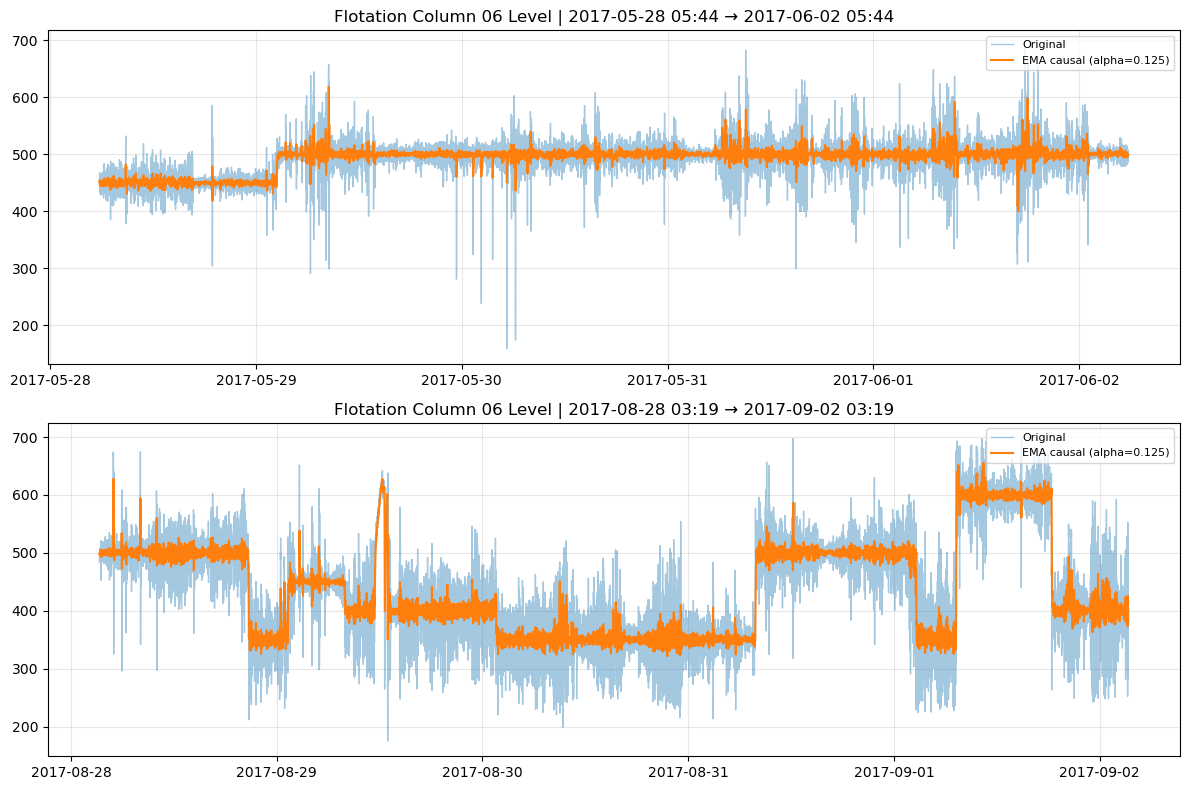

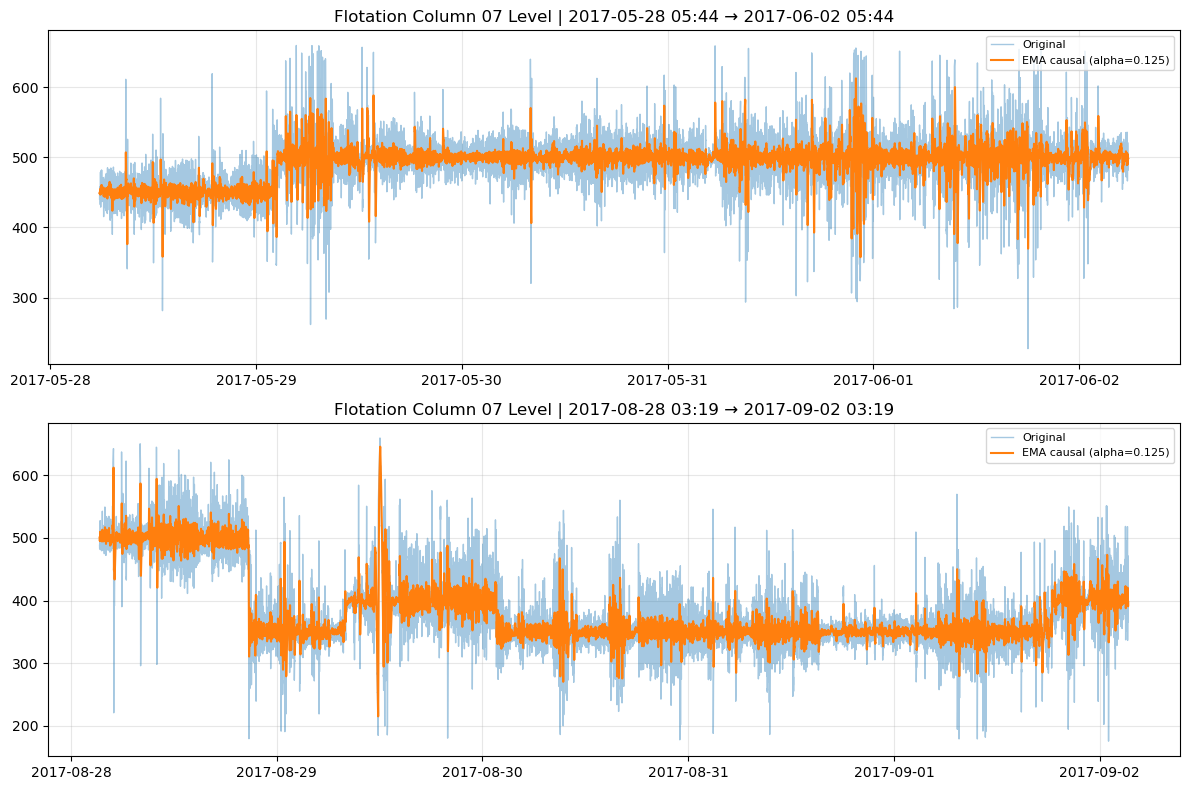

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# --- Selección de secciones random de 1 día (sobre df_raw: es donde viven los filtros) ---
np.random.seed(42)  # quita esto si quieres aleatoriedad distinta cada vez
n_sections = 2
section_duration = pd.Timedelta(days=5)

t_min = df_raw.index.min()
t_max = df_raw.index.max() - section_duration

if t_max <= t_min:
    raise ValueError("El dataset dura menos de un día, no se pueden extraer secciones de 24h")

section_starts = [
    t_min + (t_max - t_min) * np.random.rand()
    for _ in range(n_sections)
]

# --- Graficado: una figura por señal ---
for signal in sensor_cols:
    fig, axes = plt.subplots(n_sections, 1, figsize=(12, 4 * n_sections))
    if n_sections == 1:
        axes = [axes]

    for ax, start in zip(axes, section_starts):
        end = start + section_duration
        mask = (df_raw.index >= start) & (df_raw.index < end)

        ax.plot(df_raw.index[mask], df_raw[signal][mask],
                label='Original', alpha=0.4, linewidth=1)
        ax.plot(df_raw.index[mask], df_raw[signal + '_EMA'][mask],
                label=f'EMA causal (alpha={alpha:.3f})', linewidth=1.5)
        # ax.plot(df_raw.index[mask], df_raw[signal + '_SG_causal'][mask],
        #         label=f'Savitzky-Golay causal (w={windowSize})', linewidth=1.5)
        # ax.plot(df_raw.index[mask], df_raw[signal + '_SG'][mask],
        #         label=f'Savitzky-Golay centrado (w={windowSize}, no causal)',
        #         linewidth=1, linestyle='--', alpha=0.7)

        ax.set_title(f'{signal} | {start.strftime("%Y-%m-%d %H:%M")} → {end.strftime("%Y-%m-%d %H:%M")}')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Variable Selection / Feature Selection

# Filter methods

In [7]:
# VSdata: y = % Silica Concentrate, X = sensor_cols + % Iron Feed + % Silica Feed
# (se excluye % Iron Concentrate explicitamente: es otro output/target, no un input)
vs_feature_cols = sensor_cols + ['% Iron Feed', '% Silica Feed']
vs_target_col = '% Silica Concentrate'

VSdata_df = df[[vs_target_col] + vs_feature_cols].dropna()
VSdata = VSdata_df.to_numpy()

# Linear correlation
# separate X and y
y = VSdata[:, 0]
X = VSdata[:, 1:]
# compute linear correlation-based scores
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
VSmodel = SelectKBest(f_regression, k=10).fit(X, y)
input_scores = VSmodel.scores_
# find the top ranked inputs
top_k_inputs = np.argsort(input_scores)[::-1][:10] + 1
# [::-1] reverses the array returned by argsort() and [:n] gives that last n elements
# reduce X to only top relevant inputs
X_relevant = VSmodel.transform(X)

# nombres + puntuacion (f_regression score) de las top-k variables
# F crece con n (F = r^2/(1-r^2) * (n-2)), asi que no es interpretable como
# "fuerza" de la relacion, solo como significancia estadistica. Para magnitud
# interpretable, se añade r (correlacion de Pearson) y r^2 (% varianza explicada).
top_k_scores = input_scores[top_k_inputs - 1]
top_k_names = [vs_feature_cols[i - 1] for i in top_k_inputs]

n_samples = X.shape[0]
# despejando r^2 de F = r^2/(1-r^2) * (n-2)  =>  r^2 = F / (F + n - 2)
top_k_r2 = top_k_scores / (top_k_scores + n_samples - 2)
top_k_r = np.sqrt(top_k_r2) * np.sign(
    [np.corrcoef(VSdata_df[name], VSdata_df[vs_target_col])[0, 1] for name in top_k_names]
)

f_regression_ranking = pd.DataFrame({
    'feature': top_k_names,
    'f_regression_score': top_k_scores,
    'r2': top_k_r2,
    'r_pearson': top_k_r,
})
f_regression_ranking


,feature,f_regression_score,r2,r_pearson
0,Flotation Column 01 Air Flow,212.894503,0.051190,-0.226252
1,Flotation Column 03 Air Flow,212.846412,0.051179,-0.226228
2,Flotation Column 05 Level,170.588771,0.041439,-0.203567
3,Flotation Column 04 Level,147.559336,0.036047,-0.189860
4,Flotation Column 07 Level,132.822541,0.032564,-0.180455
5,Amina Flow,132.656468,0.032525,0.180346
6,Flotation Column 02 Air Flow,124.021262,0.030472,-0.174562
7,Ore Pulp pH,104.985848,0.025916,-0.160985
8,Flotation Column 06 Level,69.174756,0.017228,-0.131257
9,Starch Flow,31.891982,0.008017,-0.089539


In [8]:
# Mutual information
# captura dependencias no lineales entre cada feature y el target, a diferencia
# de f_regression (que solo mide correlacion lineal)
from sklearn.feature_selection import mutual_info_regression

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_ranking = pd.DataFrame({
    'feature': vs_feature_cols,
    'mutual_info_score': mi_scores,
}).sort_values('mutual_info_score', ascending=False).reset_index(drop=True)

top_k_mi = mi_ranking.head(10)
top_k_mi


,feature,mutual_info_score
0,% Silica Feed,0.393343
1,% Iron Feed,0.392047
2,Flotation Column 04 Air Flow,0.160274
3,Flotation Column 03 Level,0.148500
4,Flotation Column 02 Level,0.138315
5,Flotation Column 05 Air Flow,0.135509
6,Flotation Column 01 Level,0.127908
7,Flotation Column 01 Air Flow,0.115137
8,Flotation Column 04 Level,0.113858
9,Flotation Column 07 Level,0.110983


In [9]:
# Comparacion: ranking por f_regression (lineal) vs mutual_info (no lineal)
f_reg_full_ranking = pd.DataFrame({
    'feature': vs_feature_cols,
    'f_regression_score': input_scores,
}).sort_values('f_regression_score', ascending=False).reset_index(drop=True)

comparison = f_reg_full_ranking.head(10)[['feature', 'f_regression_score']].reset_index(drop=True)
comparison['feature_mi'] = mi_ranking.head(10)['feature'].values
comparison['mutual_info_score'] = mi_ranking.head(10)['mutual_info_score'].values
comparison.columns = ['top10_f_regression', 'f_regression_score', 'top10_mutual_info', 'mutual_info_score']
comparison


,top10_f_regression,f_regression_score,top10_mutual_info,mutual_info_score
0,Flotation Column 01 Air Flow,212.894503,% Silica Feed,0.393343
1,Flotation Column 03 Air Flow,212.846412,% Iron Feed,0.392047
2,Flotation Column 05 Level,170.588771,Flotation Column 04 Air Flow,0.160274
3,Flotation Column 04 Level,147.559336,Flotation Column 03 Level,0.148500
4,Flotation Column 07 Level,132.822541,Flotation Column 02 Level,0.138315
5,Amina Flow,132.656468,Flotation Column 05 Air Flow,0.135509
6,Flotation Column 02 Air Flow,124.021262,Flotation Column 01 Level,0.127908
7,Ore Pulp pH,104.985848,Flotation Column 01 Air Flow,0.115137
8,Flotation Column 06 Level,69.174756,Flotation Column 04 Level,0.113858
9,Starch Flow,31.891982,Flotation Column 07 Level,0.110983


# Wrapper methods

In [10]:
# scale data
from sklearn.preprocessing import StandardScaler
xscaler = StandardScaler()
X_scaled = xscaler.fit_transform(X)
yscaler = StandardScaler()
y_scaled = yscaler.fit_transform(y[:,None])
# implement backward SFS
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
BSFS = SequentialFeatureSelector(LinearRegression(), n_features_to_select=10, direction='backward',
cv=5).fit(X_scaled, y_scaled)
# check selected inputs
bsfs_selected_idx = BSFS.get_support(indices=True) + 1
print('Inputs selected: ', bsfs_selected_idx)

# reduce X to only top relevant inputs
X_relevant = BSFS.transform(X)

# nombres de las variables seleccionadas por BSFS
bsfs_selected_names = [vs_feature_cols[i - 1] for i in bsfs_selected_idx]
print('BSFS selected features:', bsfs_selected_names)


Inputs selected:  [ 1  2  4  5  6 10 11 17 18 21]
BSFS selected features: ['Starch Flow', 'Amina Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 05 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 05 Level', 'Flotation Column 06 Level', '% Silica Feed']


In [11]:
# implement RFE (Recursive Feature Elimination)
# mismo estimador base (LinearRegression) que BSFS, para comparar de forma justa
from sklearn.feature_selection import RFE

rfe_model = RFE(LinearRegression(), n_features_to_select=10)
rfe_model = rfe_model.fit(X_scaled, y_scaled)

# check selected inputs
rfe_selected_idx = rfe_model.get_support(indices=True) + 1

# reduce X to only top relevant inputs
X_relevant_rfe = rfe_model.transform(X)

# nombres de las variables seleccionadas por RFE
rfe_selected_names = [vs_feature_cols[i - 1] for i in rfe_selected_idx]
print('RFE selected features:', rfe_selected_names)


RFE selected features: ['Starch Flow', 'Amina Flow', 'Ore Pulp pH', 'Ore Pulp Density', 'Flotation Column 01 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 06 Air Flow', 'Flotation Column 05 Level', '% Silica Feed']


In [12]:
# Comparacion: BSFS (backward, evalua por CV) vs RFE (elimina por importancia de coeficiente)
common = sorted(set(bsfs_selected_names) & set(rfe_selected_names))
only_bsfs = sorted(set(bsfs_selected_names) - set(rfe_selected_names))
only_rfe = sorted(set(rfe_selected_names) - set(bsfs_selected_names))

print(f'Coinciden en {len(common)}/10: {common}')
print(f'Solo en BSFS: {only_bsfs}')
print(f'Solo en RFE: {only_rfe}')


Coinciden en 8/10: ['% Silica Feed', 'Amina Flow', 'Flotation Column 01 Air Flow', 'Flotation Column 05 Level', 'Flotation Column 06 Air Flow', 'Ore Pulp Density', 'Ore Pulp pH', 'Starch Flow']
Solo en BSFS: ['Flotation Column 05 Air Flow', 'Flotation Column 06 Level']
Solo en RFE: ['Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow']


### ¿Es apropiado usar un modelo lineal para el wrapper?

`f_regression` (arriba) mostró r² muy bajos (0.6%–4.9%) para todas las variables,
y `mutual_info` detectó relaciones relevantes (`% Silica Feed`) que la correlacion
lineal no capta bien. Eso sugiere que la relacion real no es predominantemente
lineal, asi que un RFE con `LinearRegression` puede estar seleccionando variables
sesgado por ese supuesto. Se repite el RFE con `RandomForestRegressor` (captura
no linealidad e interacciones, no necesita escalado) para comparar.


In [13]:
# RFE con RandomForestRegressor (no lineal, captura interacciones)
# No hace falta escalar: los arboles son invariantes a la escala de las features.
from sklearn.ensemble import RandomForestRegressor

rfe_rf_model = RFE(
    RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    n_features_to_select=10,
)
rfe_rf_model = rfe_rf_model.fit(X, y)

rfe_rf_selected_idx = rfe_rf_model.get_support(indices=True) + 1
rfe_rf_selected_names = [vs_feature_cols[i - 1] for i in rfe_rf_selected_idx]
print('RFE (RandomForest) selected features:', rfe_rf_selected_names)


RFE (RandomForest) selected features: ['Starch Flow', 'Amina Flow', 'Ore Pulp pH', 'Flotation Column 01 Air Flow', 'Flotation Column 03 Air Flow', 'Flotation Column 04 Air Flow', 'Flotation Column 03 Level', 'Flotation Column 05 Level', 'Flotation Column 07 Level', '% Silica Feed']


In [14]:
# Comparacion de tres vias: BSFS lineal vs RFE lineal vs RFE no lineal (RF)
all_features = set(bsfs_selected_names) | set(rfe_selected_names) | set(rfe_rf_selected_names)

wrapper_comparison = pd.DataFrame({
    'feature': sorted(all_features),
})
wrapper_comparison['BSFS_linear'] = wrapper_comparison['feature'].isin(bsfs_selected_names)
wrapper_comparison['RFE_linear'] = wrapper_comparison['feature'].isin(rfe_selected_names)
wrapper_comparison['RFE_random_forest'] = wrapper_comparison['feature'].isin(rfe_rf_selected_names)
wrapper_comparison['n_methods_agree'] = wrapper_comparison[
    ['BSFS_linear', 'RFE_linear', 'RFE_random_forest']
].sum(axis=1)

wrapper_comparison = wrapper_comparison.sort_values(
    'n_methods_agree', ascending=False
).reset_index(drop=True)
wrapper_comparison


,feature,BSFS_linear,RFE_linear,RFE_random_forest,n_methods_agree
0,% Silica Feed,True,True,True,3
1,Amina Flow,True,True,True,3
2,Flotation Column 01 Air Flow,True,True,True,3
3,Flotation Column 05 Level,True,True,True,3
4,Ore Pulp pH,True,True,True,3
5,Starch Flow,True,True,True,3
6,Flotation Column 03 Air Flow,False,True,True,2
7,Flotation Column 04 Air Flow,False,True,True,2
8,Flotation Column 06 Air Flow,True,True,False,2
9,Ore Pulp Density,True,True,False,2


# Outlier handling

# Univariate methods

# Multivariate methods

# Data mining methods

In [15]:
# FAST-MCD algorithm

# compute MCD-based Mahalanobis distances
from sklearn.covariance import MinCovDet
MCD_cov = MinCovDet().fit(df[sensor_cols])
MD_MCD = MCD_cov.mahalanobis(df[sensor_cols])